# Replace & Change Data Type

`04_Data_Cleaning.MD` files this under sub-skill #6, **Dealing with
Inconsistent Data** — a column that's fully *present* but encoded in a
way a model (or `astype()`) can't use as-is. `loans.csv`'s `Dependents`
column is exactly that: four categories where three are digits (`0`,
`1`, `2`) and the fourth is `"3+"` — a string a numeric dtype has no way
to parse.

Two separate operations, easy to blur together:

| Operation | Question it answers | Method |
|---|---|---|
| **Replace** | "Same column, different *values*?" | `.replace(old, new)` |
| **Change dtype** | "Same values, different *storage type*?" | `.astype(dtype)` |

`"3+"` needs both, in that order: replace the value with something
numeric-looking (`"3"`), *then* convert the column to `int64`. Reverse
the order and `astype()` throws — it still has `"3+"` to parse.

This notebook also exists because the first attempt got the values right
but the DataFrame never actually changed — a genuine Copy-on-Write bug in
the `dataset["col"].replace(..., inplace=True)` pattern, not a dtype
problem despite what the resulting error looked like. Section 1
reproduces that bug on purpose before Section 2 touches the real data.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

## 1. The Copy-on-Write Trap — A Controlled Repro

Before touching `loans.csv`, reproduce the actual bug on a throwaway
3-row DataFrame: does `.replace(..., inplace=True)` on a *column
selection* (`df["col"]`) really leave the DataFrame unchanged? Small
enough to see every step.

In [2]:
demo = pd.DataFrame({"bucket": ["0", "1", "3+"]})
demo

,bucket
0,0
1,1
2,3+


Call `.replace()` chained off the column selection — exactly the way
it's tempting to write it:

In [3]:
demo["bucket"].replace("3+", "3", inplace=True)
demo

/var/folders/07/ymtnct793nj_13sf3p9t0lqh0000gn/T/ipykernel_35352/597682250.py:1: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  demo["bucket"].replace("3+", "3", inplace=True)


,bucket
0,0
1,1
2,3+


The warning names the exact problem: `demo["bucket"]` builds a temporary
copy under pandas' Copy-on-Write rules, and `inplace=True` only mutates
*that* copy — `demo` itself never sees the change. `"3+"` is still
sitting in the real DataFrame, confirmed by the output above. This is
the same failure the real `Dependents` column hit originally:
`value_counts()` kept showing `3+` no matter how many times the
`inplace=True` cell was re-run, and the follow-up `astype("int64")` then
failed trying to parse a `"3+"` that was never actually removed.

The fix: don't chain — reassign the column instead.

In [4]:
demo["bucket"] = demo["bucket"].replace("3+", "3")
demo

,bucket
0,0
1,1
2,3


Same method, same arguments — the only change is
`demo["bucket"] = ...` instead of `inplace=True`. No warning, and
`"3+"` is actually gone this time. That's the pattern used on the real
column below.

## 2. Real Data — `loans.csv`'s `Dependents` Column

Load, check dtype, check for missing values, check the categories
actually present — same order as the toy example, on the real
column.

In [5]:
dataset = pd.read_csv("loans.csv")
dataset.head(3)

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001001,Male,Yes,0,Not Graduate,No,1686.0,1020,80.0,360.0,1.0,Semiurban,Y
1,LP001002,Male,Yes,0,Not Graduate,No,2437.0,1201,122.0,360.0,1.0,Urban,Y
2,LP001003,Female,No,0,Graduate,No,8313.0,1065,319.0,360.0,1.0,Urban,Y


In [6]:
dataset.info()

<class 'pandas.DataFrame'>
RangeIndex: 618 entries, 0 to 617
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            618 non-null    str    
 1   Gender             605 non-null    str    
 2   Married            612 non-null    str    
 3   Dependents         603 non-null    str    
 4   Education          609 non-null    str    
 5   Self_Employed      586 non-null    str    
 6   ApplicantIncome    616 non-null    float64
 7   CoapplicantIncome  618 non-null    int64  
 8   LoanAmount         596 non-null    float64
 9   Loan_Amount_Term   597 non-null    float64
 10  Credit_History     568 non-null    float64
 11  Property_Area      609 non-null    str    
 12  Loan_Status        618 non-null    str    
dtypes: float64(4), int64(1), str(8)
memory usage: 62.9 KB


`Dtype: str` here — not the classic `object` dtype pandas showed before
its newer string backend, but that distinction isn't the bug: chained
`inplace=True` breaks identically regardless of dtype, as Section 1 just
showed with a plain toy DataFrame. What *does* matter from this output:
`Dependents` is `603` non-null out of `618` rows — `15` missing —
confirmed next by `isnull().sum()`.

In [7]:
dataset.isnull().sum()

Loan_ID               0
Gender               13
Married               6
Dependents           15
Education             9
Self_Employed        32
ApplicantIncome       2
CoapplicantIncome     0
LoanAmount           22
Loan_Amount_Term     21
Credit_History       50
Property_Area         9
Loan_Status           0
dtype: int64

In [8]:
dataset["Dependents"].value_counts()

Dependents
0     356
2     108
1      82
3+     57
Name: count, dtype: int64

Four categories, but only three (`0`, `1`, `2`) are digits — `3+` is
deliberately non-numeric (a household could have more than 3
dependents, but the source data caps the label instead of guessing an
exact count). Counts add up to `356 + 108 + 82 + 57 = 603` — matching
the `603` non-null count from `.info()` above; the other `15` rows are
the missing values `isnull().sum()` just confirmed. Two separate
problems to fix, in order: the missing `15` first, then the `3+` label.

In [9]:
dataset["Dependents"] = dataset["Dependents"].fillna(dataset["Dependents"].mode()[0])

In [10]:
dataset["Dependents"].value_counts()

Dependents
0     371
2     108
1      82
3+     57
Name: count, dtype: int64

`0` grew from `356` → `371` — exactly the `15` previously-missing rows,
now filled with the column's mode (`"0"`, the most common value). Every
other category is untouched; `.mode()[0]` only ever fills gaps, never
overwrites a value that was already there. `3+` is still `57` — next.

In [11]:
dataset["Dependents"] = dataset["Dependents"].replace("3+", "3")

In [12]:
dataset["Dependents"].value_counts()

Dependents
0    371
2    108
1     82
3     57
Name: count, dtype: int64

`3+` → `3`. Still `57` rows, same position in the distribution — only
the label changed, not which rows belong to it. Confirmed by reassigning
rather than chaining `inplace=True`, per the repro in Section 1. Every
value in the column is now a plain digit string (`"0"`–`"3"`), and there
are no more missing rows — ready for `astype()`.

## 3. Changing the Dtype

Values are numeric-looking now (`"0"`, `"1"`, `"2"`, `"3"`), but the
column is still text — `astype("int64")` is the step that actually
changes storage type. Worth checking what that buys beyond "the
`ValueError` goes away": dtype and memory footprint, before and after.

In [13]:
before_dtype = dataset["Dependents"].dtype
before_mem = dataset["Dependents"].memory_usage(deep=True)
before_dtype, before_mem

(<StringDtype(storage='python', na_value=nan)>, 31032)

In [14]:
dataset["Dependents"] = dataset["Dependents"].astype("int64")

In [15]:
after_dtype = dataset["Dependents"].dtype
after_mem = dataset["Dependents"].memory_usage(deep=True)
after_dtype, after_mem

(dtype('int64'), 5076)

Same 618 values, two different storage types — and a smaller memory
footprint isn't the only payoff. A `str`-dtype column can't run numeric
methods at all; try `.mean()` before conversion and pandas has no
sensible way to average `"0"` and `"3"` as text. After `astype("int64")`
it's a one-line call.

In [16]:
dataset["Dependents"].mean()

np.float64(0.7588996763754046)

That number only exists because the column is `int64` now — it would
have raised on the original `"3+"`-containing text column, and even on
the cleaned-but-still-`str` version just before `astype()`. Two
visualizations to close out: the memory difference from above, and what
the fully cleaned distribution looks like.

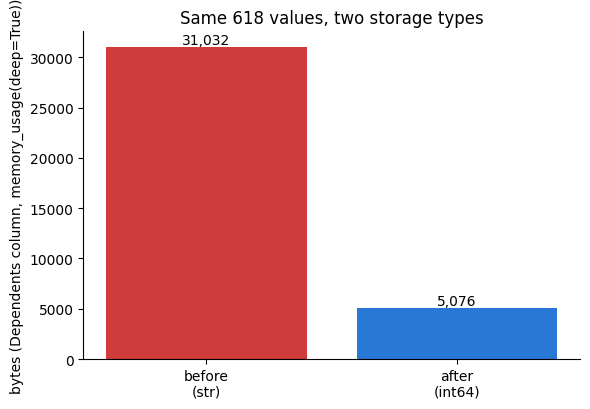

In [17]:
fig, ax = plt.subplots(figsize=(6, 4.2))
mem = {"before\n(str)": before_mem, "after\n(int64)": after_mem}
bars = ax.bar(mem.keys(), mem.values(), color=["#d03b3b", "#2a78d6"])
ax.set_ylabel("bytes (Dependents column, memory_usage(deep=True))")
ax.set_title("Same 618 values, two storage types")
for b in bars:
    ax.text(b.get_x() + b.get_width() / 2, b.get_height() + max(mem.values()) * 0.01,
             f"{int(b.get_height()):,}", ha="center")
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

`31,032` bytes as `str` → `5,076` bytes as `int64` — about **83% less**
memory for the exact same 618 values. `int64` stores each entry as a
fixed 8-byte number; the string version pays for Python string-object
overhead per row on top of the actual digit. Small on one column,
compounding fast across a real dataset with many categorical-looking
numeric columns. And separately from size: `dataset["Dependents"].mean()`
now returns `0.759` — a real number, only possible because the dtype is
genuinely numeric, not text that merely looks like digits.

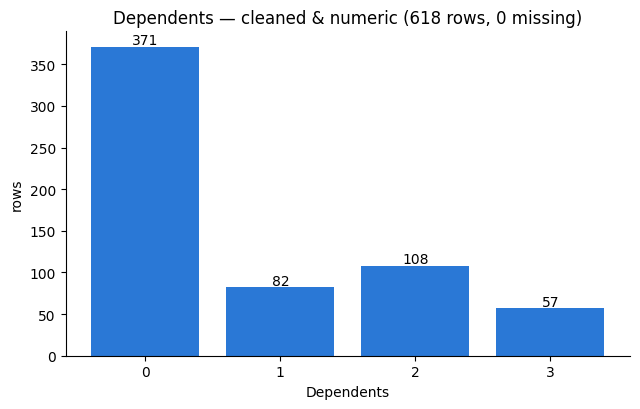

In [18]:
counts_after = dataset["Dependents"].value_counts().sort_index()
plt.figure(figsize=(6.5, 4.2))
bars = plt.bar(counts_after.index.astype(str), counts_after.values, color="#2a78d6")
plt.xlabel("Dependents")
plt.ylabel("rows")
plt.title("Dependents — cleaned & numeric (618 rows, 0 missing)")
for b in bars:
    plt.text(b.get_x() + b.get_width() / 2, b.get_height() + 3,
              str(int(b.get_height())), ha="center")
plt.gca().spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

All four bars now line up on plain integer labels (`0`–`3`), x-axis
sorted ascending, no `3+` in sight and no gap for the `15` rows that
used to be missing — every one of the 618 rows lands in exactly one
bucket.

## Summary

- **`.replace()`** changes *values*; **`.astype()`** changes *storage
  type*. `"3+"` needed both, in that order — `astype("int64")` can't
  parse a `+`, so replace has to run first.
- **Copy-on-Write trap:** `df["col"].method(..., inplace=True)` silently
  no-ops — `df["col"]` builds a temporary copy, and `inplace=True` only
  mutates that copy, never the real DataFrame. Reassign instead:
  `df["col"] = df["col"].method(...)`. Reproduced deliberately on a toy
  3-row DataFrame in Section 1 before touching real data, because this
  is exactly the bug that made the original `Dependents` cleanup look
  broken.
- `fillna(mode)` moved the `15` missing rows into the `"0"` bucket
  (`356 → 371`); every other category was untouched.
- `replace("3+", "3")` relabeled the `57`-row bucket without moving any
  rows — same count, same position, just a parseable value.
- `astype("int64")` is the step that actually changes storage: smaller
  memory footprint (measured directly via `memory_usage(deep=True)`),
  and it's what turns `.mean()` from a `TypeError` into a real number —
  numeric methods only work on a genuinely numeric dtype, not a string
  that merely *looks* numeric.